# Домашнее задание "Центральная предельная теорема и статистика".

## Задание.

В этом задании нужно убедиться, что ЦПТ действительно работает.

Создайте случайную величину из [любого выбранного вами распределения](https://docs.scipy.org/doc/scipy/reference/stats.html), для разных значений `n` сгенерируйте 1000 выборок размера `n`. Постройте гистрограммы средних этих выборок и сделайте выводы.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts
%matplotlib inline

In [2]:
rv = sts.expon(loc=10, scale=15)
sample = rv.rvs(size=1000)

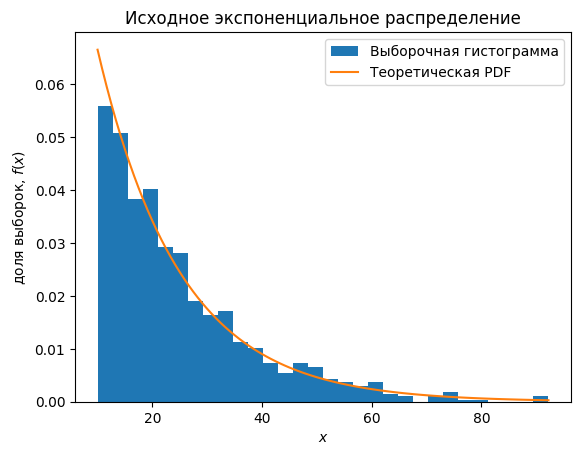

In [3]:
# Визуализация исходной выборки и теоретической PDF
x = np.linspace(sample.min(), sample.max(), 100)
pdf = rv.pdf(x)
plt.figure()
plt.hist(sample, density=True, bins=30, label='Выборочная гистограмма')
plt.plot(x, pdf, label='Теоретическая PDF', alpha=1)
plt.legend()
plt.ylabel('доля выборок, $f(x)$')
plt.xlabel('$x$')
plt.title('Исходное экспоненциальное распределение')
plt.show()

In [4]:
# Параметры исходного распределения (для нормальной аппроксимации)
mu = rv.mean()        # матожидание = loc + scale = 10 + 15 = 25
sigma = rv.std()      # стандартное отклонение = scale = 15

In [5]:
# Размеры выборок для демонстрации ЦПТ
sample_sizes = [10, 100, 1000]
colors = ['blue', 'green', 'red']

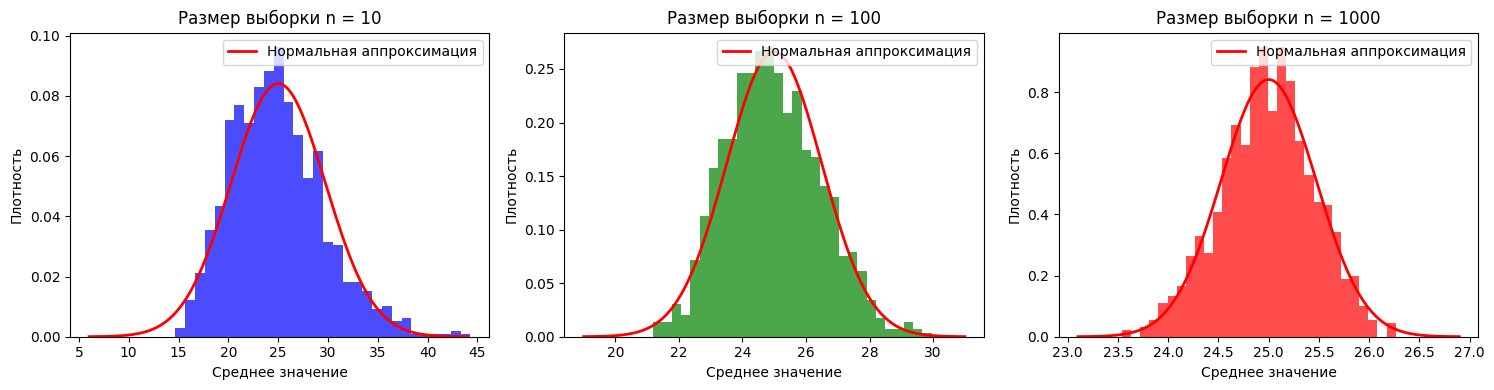

In [6]:
# Создание подграфиков (1 строка, 3 столбца)
fig, axes = plt.subplots(1, len(sample_sizes), figsize=(15, 4))

for i, n in enumerate(sample_sizes):
    # Генерация 1000 выборочных средних
    means = [rv.rvs(size=n).mean() for _ in range(1000)]
    
    # Построение гистограммы выборочных средних
    axes[i].hist(means, density=True, bins=30, alpha=0.7, color=colors[i])
    
    # Добавление нормальной аппроксимации: N(mu, sigma/sqrt(n))
    se = sigma / np.sqrt(n)   # стандартная ошибка среднего
    x_norm = np.linspace(mu - 4*se, mu + 4*se, 200)
    axes[i].plot(x_norm, sts.norm.pdf(x_norm, mu, se), 'r-', lw=2, label='Нормальная аппроксимация')
    
    axes[i].set_title(f'Размер выборки n = {n}')
    axes[i].set_xlabel('Среднее значение')
    axes[i].set_ylabel('Плотность')
    axes[i].legend()

plt.tight_layout()
plt.show()

## Выводы

1. **Центральная предельная теорема (ЦПТ)** утверждает, что распределение выборочных средних для независимых одинаково распределённых случайных величин с конечной дисперсией стремится к нормальному распределению при увеличении размера выборки n.

2. **Результаты эксперимента**:  
   - При n = 10 гистограмма выборочных средних ещё заметно асимметрична и отличается от нормальной формы (хотя уже смещена в сторону симметрии).  
   - При n = 100 форма гистограммы становится более симметричной и близкой к нормальной кривой (красная линия).  
   - При n = 1000 распределение выборочных средних практически неотличимо от нормального с тем же математическим ожиданием (примерно 25) и уменьшающейся дисперсией (дисперсия равна дисперсии исходного распределения, делённой на n).

3. **Уменьшение разброса**: С ростом n стандартная ошибка среднего (стандартное отклонение исходного распределения, делённое на корень из n) убывает, поэтому гистограммы становятся уже и выше — средние значения концентрируются вокруг математического ожидания (25). Это хорошо видно на подграфиках.

4. **Нормальная аппроксимация**: На каждом подграфике добавлена теоретическая кривая нормального распределения с теми же параметрами (математическое ожидание 25 и дисперсия, равная дисперсии исходного распределения, делённой на n). Видно, что при n=1000 гистограмма и кривая практически совпадают, что подтверждает ЦПТ.

Таким образом, ЦПТ действительно работает для экспоненциального распределения (у которого дисперсия конечна). С увеличением объёма выборки распределение средних сходится к нормальному.